In [46]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## 1. Параметры и пути

In [47]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
RUNS_PATH = DATA_DIR / "meta" / "runs.csv"
CITY_DATA_PATH = DATA_DIR / "indices_in_big_cities.xlsx"

RANDOM_STATE = 42
GRAPH_KINDS = ["barabasi_albert_graph", "watts_strogatz_graph"]

SYNTHETIC_DAYS_BEFORE_PEAK = 35 + 14
SYNTHETIC_DAYS_AFTER_PEAK = 14 + 28
DAYS_PER_WEEK_BIN = 7
N_WEEKLY_POINTS = (SYNTHETIC_DAYS_BEFORE_PEAK + SYNTHETIC_DAYS_AFTER_PEAK) // DAYS_PER_WEEK_BIN

#CITY_START_YEAR = 2000
CITY_START_YEAR = 1985
EPIDEMIC_MARKS = {"Э"}
CITY_WEEKS_BEFORE_PEAK = 5 + 2
CITY_WEEKS_AFTER_PEAK = 2 + 4
CITY_WINDOW_POINTS = CITY_WEEKS_BEFORE_PEAK + CITY_WEEKS_AFTER_PEAK

EXPECTED_CITY_WAVES = 42
WEAK_PERCENTILE = 10
TEST_SIZE = 0.2

## 2. Общие функции обработки формы волны

In [48]:
def clean_curve(y):
    """Приводит ряд к числовому массиву: убирает пропуски, бесконечности и отрицательные значения."""
    arr = (
        pd.to_numeric(pd.Series(y), errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .to_numpy(dtype=float, copy=True)
    )
    arr[arr < 0] = 0
    return arr


def normalize_shape(y):
    """Нормирует кривую на максимум."""
    arr = clean_curve(y)
    if arr.size == 0 or np.nanmax(arr) <= 0:
        return np.zeros_like(arr, dtype=float)
    return arr / np.nanmax(arr)


def fixed_window_around_peak(y, points_before_peak, points_after_peak):
    """Вырезает фиксированное окно вокруг пика; возвращает пустой ряд, если окно не помещается."""
    arr = clean_curve(y)
    if arr.size == 0 or np.nanmax(arr) <= 0:
        return arr[:0], 0, -1
    peak_idx = int(np.nanargmax(arr))
    start_idx = peak_idx - points_before_peak
    end_exclusive = peak_idx + points_after_peak
    if start_idx < 0 or end_exclusive > arr.size:
        return arr[:0], max(0, start_idx), min(arr.size - 1, end_exclusive - 1)
    return arr[start_idx:end_exclusive], start_idx, end_exclusive - 1


def daily_window_to_weekly_shape(daily_window, days_per_bin=DAYS_PER_WEEK_BIN):
    """Агрегирует дневные точки синтетики в недельные средние и нормирует форму."""
    arr = clean_curve(daily_window)
    if arr.size != N_WEEKLY_POINTS * days_per_bin:
        return arr[:0]
    weekly = arr.reshape(N_WEEKLY_POINTS, days_per_bin).mean(axis=1)
    return normalize_shape(weekly)

## 3. Загрузка синтетических кривых

In [70]:
runs_df = pd.read_csv(RUNS_PATH)
synthetic_records = []

for row in runs_df.itertuples(index=False):
    graph_kind = str(row.graph_kind)
    if graph_kind not in GRAPH_KINDS:
        continue

    curve_path = DATA_DIR / str(row.relative_path)
    curve_df = pd.read_csv(curve_path)

    daily_window, start_idx, end_idx = fixed_window_around_peak(
        curve_df["I"],
        SYNTHETIC_DAYS_BEFORE_PEAK,
        SYNTHETIC_DAYS_AFTER_PEAK,
    )
    weekly_shape = daily_window_to_weekly_shape(daily_window)
    if weekly_shape.size != N_WEEKLY_POINTS or np.nanmax(weekly_shape) <= 0:
        continue

    synthetic_records.append(
        {
            "synthetic_id": len(synthetic_records),
            "label": graph_kind,
            "lam": pd.to_numeric(row.lam, errors="coerce"),
            "seed_in_graph": int(row.seed_in_graph),
            "daily_start_idx": start_idx,
            "daily_end_idx": end_idx,
            "shape": weekly_shape,
        }
    )

synthetic_df = pd.DataFrame(synthetic_records)
synthetic_matrix = np.vstack(synthetic_df["shape"].to_numpy())

print(f"Количество используемых синтетических кривых: {len(synthetic_df):,}")
display(synthetic_df.groupby(["label", "lam"]).size().rename("n").reset_index())

Количество используемых синтетических кривых: 2,378


,label,lam,n
0,barabasi_albert_graph,1.0,241
1,barabasi_albert_graph,2.0,247
2,barabasi_albert_graph,4.0,250
3,barabasi_albert_graph,8.0,249
4,barabasi_albert_graph,16.0,216
5,barabasi_albert_graph,32.0,160
6,barabasi_albert_graph,64.0,30
7,watts_strogatz_graph,1.0,69
8,watts_strogatz_graph,2.0,103
9,watts_strogatz_graph,4.0,149


## 4. Загрузка городских данных и выделение эпидемических волн

In [71]:
def load_city_data(path):
    """Загружает XLSX/CSV с городскими рядами."""
    if path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(path)
    elif path.suffix.lower() == ".csv":
        df = pd.read_csv(path, delimiter=";")
    else:
        raise ValueError(f"Неизвестный формат городских данных: {path.suffix}")

    for column in ["cld_year", "week_number", "wd_total", "qty_total"]:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    return (
        df[df["cld_year"] >= CITY_START_YEAR]
        .sort_values(["town_name", "cld_year", "week_number"])
        .reset_index(drop=True)
    )


def smooth_city_series(group):
    """Сглаживает недельный городской ряд wd_total."""
    group = group.sort_values(["cld_year", "week_number"]).copy()
    y = group["wd_total"].astype(float)
    return (
        y.interpolate(limit_direction="both")
        .rolling(window=5, center=True, min_periods=1)
        .median()
        .rolling(window=3, center=True, min_periods=1)
        .mean()
        .to_numpy(dtype=float)
    )


def epidemic_segments(group):
    """Находит непрерывные интервалы недель, помеченных как эпидемические."""
    epidemic_mask = group["wda_total"].astype(str).isin(EPIDEMIC_MARKS).to_numpy()
    segments = []
    i = 0

    while i < len(epidemic_mask):
        if not epidemic_mask[i]:
            i += 1
            continue
        start = i
        while i + 1 < len(epidemic_mask) and epidemic_mask[i + 1]:
            i += 1
        end = i
        segments.append((start, end))
        i += 1

    return segments

In [72]:
city_df = load_city_data(CITY_DATA_PATH)
city_wave_records = []

for city, group in city_df.groupby("town_name"):
    group = group.sort_values(["cld_year", "week_number"]).reset_index(drop=True)
    series = smooth_city_series(group)
    waves = []

    for epidemic_start_idx, epidemic_end_idx in epidemic_segments(group):
        epidemic_segment = series[epidemic_start_idx : epidemic_end_idx + 1]
        if epidemic_segment.size == 0 or np.nanmax(epidemic_segment) <= 0:
            continue

        peak_idx = epidemic_start_idx + int(np.nanargmax(epidemic_segment))
        start_idx = peak_idx - CITY_WEEKS_BEFORE_PEAK
        end_exclusive = peak_idx + CITY_WEEKS_AFTER_PEAK

        if start_idx < 0 or end_exclusive > len(series):
            continue

        window = series[start_idx:end_exclusive]
        if window.size != CITY_WINDOW_POINTS or np.nanmax(window) <= 0:
            continue

        waves.append(
            {
                "city": city,
                "start_idx": start_idx,
                "end_idx": end_exclusive - 1,
                "peak_idx": peak_idx,
                "epidemic_start_idx": epidemic_start_idx,
                "epidemic_end_idx": epidemic_end_idx,
                "peak_value": float(series[peak_idx]),
                "shape": normalize_shape(window),
            }
        )

    for wave_id, wave in enumerate(sorted(waves, key=lambda item: item["start_idx"]), start=1):
        start_row = group.iloc[wave["start_idx"]]
        end_row = group.iloc[wave["end_idx"]]
        peak_row = group.iloc[wave["peak_idx"]]

        city_wave_records.append(
            {
                "wave_id": wave_id,
                "city": city,
                "start_year": int(start_row["cld_year"]),
                "start_week": int(start_row["week_number"]),
                "end_year": int(end_row["cld_year"]),
                "end_week": int(end_row["week_number"]),
                "peak_year": int(peak_row["cld_year"]),
                "peak_week": int(peak_row["week_number"]),
                "peak_value": wave["peak_value"],
                "shape": wave["shape"],
            }
        )

city_waves = pd.DataFrame(city_wave_records)
city_matrix = np.vstack(city_waves["shape"].to_numpy())

print(f"Строк после {CITY_START_YEAR} года: {len(city_df):,}")
print(f"Найдено городских волн: {len(city_waves):,}")
if len(city_waves) != EXPECTED_CITY_WAVES:
    warnings.warn(
        f"Ожидалось {EXPECTED_CITY_WAVES} городские волны по baseline-анализу, найдено {len(city_waves)}."
    )
display(city_waves[["city", "wave_id", "peak_year", "peak_week", "peak_value"]].head(12))

Строк после 1985 года: 20,028
Найдено городских волн: 325


,city,wave_id,peak_year,peak_week,peak_value
0,Екатеринбург,1,1986,47,19472.000000
1,Екатеринбург,2,1988,8,31723.000000
2,Екатеринбург,3,1989,9,21734.000000
3,Екатеринбург,4,1989,52,9864.333333
4,Екатеринбург,5,1990,5,19993.000000
5,Екатеринбург,6,1991,13,21231.000000
6,Екатеринбург,7,1991,52,14041.000000
7,Екатеринбург,8,1993,11,18826.000000
8,Екатеринбург,9,1994,7,14032.000000
9,Екатеринбург,10,1995,9,9709.000000


## 5. Признаки формы волны

In [73]:
def curve_feature_row(shape):
    """Строит ML-признаки из нормированной формы волны."""
    arr = np.asarray(shape, dtype=float)
    if arr.size != CITY_WINDOW_POINTS:
        raise ValueError(f"Ожидалась форма длины {CITY_WINDOW_POINTS}, получена {arr.size}")
    if not np.isfinite(arr).all():
        raise ValueError("Форма содержит NaN или inf")

    peak_idx = int(np.nanargmax(arr))
    pre_segment = arr[: peak_idx + 1]
    post_segment = arr[peak_idx:]

    pre_area = float(np.trapezoid(pre_segment)) if pre_segment.size > 1 else float(pre_segment.sum())
    post_area = float(np.trapezoid(post_segment)) if post_segment.size > 1 else float(post_segment.sum())
    total_area = pre_area + post_area

    early_growth = (
        float((arr[peak_idx] - arr[0]) / peak_idx)
        if peak_idx > 0
        else 0.0
    )
    post_peak_decay = (
        float((arr[peak_idx] - arr[-1]) / (arr.size - 1 - peak_idx))
        if peak_idx < arr.size - 1
        else 0.0
    )

    features = {f"shape_{i:02d}": float(value) for i, value in enumerate(arr)}
    features.update(
        {
            "pre_peak_area": pre_area,
            "post_peak_area": post_area,
            "area_asymmetry": float((post_area - pre_area) / total_area) if total_area > 0 else 0.0,
            "early_growth": early_growth,
            "post_peak_decay": post_peak_decay,
            "width_above_50": float(np.mean(arr >= 0.50)),
            "width_above_75": float(np.mean(arr >= 0.75)),
            "tail_level": float(arr[-1]),
        }
    )
    return features


def build_feature_frame(source_df):
    feature_df = pd.DataFrame([curve_feature_row(shape) for shape in source_df["shape"]])
    return feature_df.astype(float)


def validate_feature_frame(name, feature_df):
    finite = np.isfinite(feature_df.to_numpy(dtype=float)).all()
    if not finite:
        raise ValueError(f"{name} содержит NaN или inf")
    if feature_df.isna().any().any():
        raise ValueError(f"{name} содержит пропуски")
    print(f"{name}: {feature_df.shape[0]:,} строк, {feature_df.shape[1]:,} признаков, NaN/inf нет")


synthetic_features = build_feature_frame(synthetic_df)
city_features = build_feature_frame(city_waves)
FEATURE_COLUMNS = synthetic_features.columns.tolist()
city_features = city_features.reindex(columns=FEATURE_COLUMNS)

validate_feature_frame("synthetic_features", synthetic_features)
validate_feature_frame("city_features", city_features)
display(synthetic_features.head())

synthetic_features: 2,378 строк, 21 признаков, NaN/inf нет
city_features: 325 строк, 21 признаков, NaN/inf нет


,shape_00,shape_01,shape_02,shape_03,shape_04,shape_05,shape_06,shape_07,shape_08,shape_09,...,shape_11,shape_12,pre_peak_area,post_peak_area,area_asymmetry,early_growth,post_peak_decay,width_above_50,width_above_75,tail_level
0,0.534381,0.629339,0.742960,0.859528,0.963982,0.980681,1.000000,0.946955,0.886379,0.835953,...,0.759332,0.658481,4.943680,5.084971,0.014089,0.077603,0.056920,1.000000,0.692308,0.658481
1,0.365814,0.467520,0.600066,0.719488,0.867454,0.986220,1.000000,1.000000,0.960302,0.907480,...,0.863189,0.784449,4.323655,5.498196,0.119584,0.105698,0.035925,0.846154,0.692308,0.784449
2,0.410458,0.532126,0.723172,0.842789,0.928230,0.965140,0.979152,1.000000,0.942925,0.925837,...,0.789474,0.699248,5.675837,4.345865,-0.132709,0.084220,0.060150,0.923077,0.692308,0.699248
3,0.550818,0.674575,0.799615,0.889388,0.952549,0.985893,0.961526,0.982687,0.994229,1.000000,...,0.809234,0.716255,8.015870,2.582398,-0.512675,0.049909,0.094582,1.000000,0.769231,0.716255
4,0.275449,0.403892,0.499401,0.600000,0.721557,0.858383,0.965269,1.000000,0.989222,0.985329,...,0.850599,0.779940,4.686228,4.675599,-0.001135,0.103507,0.044012,0.769231,0.615385,0.779940


## 6. Обучение классификатора

In [74]:
strata = synthetic_df["label"].astype(str) + "|lam=" + synthetic_df["lam"].astype(str)
train_idx, test_idx = train_test_split(
    synthetic_df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=strata,
)

X_train = synthetic_features.loc[train_idx, FEATURE_COLUMNS].reset_index(drop=True)
X_test = synthetic_features.loc[test_idx, FEATURE_COLUMNS].reset_index(drop=True)
y_train = synthetic_df.loc[train_idx, "label"].reset_index(drop=True)
y_test = synthetic_df.loc[test_idx, "label"].reset_index(drop=True)

base_classifier = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

calibrated_model = CalibratedClassifierCV(
    estimator=base_classifier,
    method="sigmoid",
    cv=5,
    n_jobs=-1,
)

calibrated_model.fit(X_train, y_train)
print(f"Train synthetic curves: {len(X_train):,}")
print(f"Holdout synthetic curves: {len(X_test):,}")
print(f"Классы модели: {list(calibrated_model.classes_)}")

Train synthetic curves: 1,902
Holdout synthetic curves: 476
Классы модели: ['barabasi_albert_graph', 'watts_strogatz_graph']


## 7. Оценка на synthetic holdout

In [75]:
classes = np.asarray(calibrated_model.classes_)
test_proba = calibrated_model.predict_proba(X_test)
test_pred = classes[np.argmax(test_proba, axis=1)]
sorted_test_proba = np.sort(test_proba, axis=1)
test_confidence = sorted_test_proba[:, -1]
test_margin = (
    sorted_test_proba[:, -1] - sorted_test_proba[:, -2]
    if len(classes) > 1
    else np.ones(len(test_proba), dtype=float)
)

accuracy = accuracy_score(y_test, test_pred)
balanced_accuracy = balanced_accuracy_score(y_test, test_pred)
roc_auc = np.nan
if len(classes) == 2:
    positive_class = classes[1]
    roc_auc = roc_auc_score((y_test == positive_class).astype(int), test_proba[:, 1])

synthetic_eval = pd.DataFrame(
    [
        {"metric": "accuracy", "value": accuracy},
        {"metric": "balanced_accuracy", "value": balanced_accuracy},
        {"metric": "roc_auc", "value": roc_auc},
        {"metric": "n_train", "value": len(X_train)},
        {"metric": "n_holdout", "value": len(X_test)},
    ]
)

synthetic_holdout_predictions = synthetic_df.loc[
    test_idx, ["synthetic_id", "label", "lam", "seed_in_graph"]
].reset_index(drop=True)
synthetic_holdout_predictions["predicted_class"] = test_pred
synthetic_holdout_predictions["confidence"] = test_confidence
synthetic_holdout_predictions["probability_margin"] = test_margin
synthetic_holdout_predictions["is_correct"] = synthetic_holdout_predictions["label"] == synthetic_holdout_predictions["predicted_class"]
for class_idx, class_name in enumerate(classes):
    synthetic_holdout_predictions[f"prob_{class_name}"] = test_proba[:, class_idx]

print("Synthetic holdout metrics:")
display(synthetic_eval)
print("Classification report:")
print(classification_report(y_test, test_pred))

Synthetic holdout metrics:


,metric,value
0,accuracy,0.844538
1,balanced_accuracy,0.848012
2,roc_auc,0.931782
3,n_train,1902.000000
4,n_holdout,476.000000


Classification report:
                       precision    recall  f1-score   support

barabasi_albert_graph       0.90      0.83      0.86       278
 watts_strogatz_graph       0.78      0.87      0.82       198

             accuracy                           0.84       476
            macro avg       0.84      0.85      0.84       476
         weighted avg       0.85      0.84      0.85       476



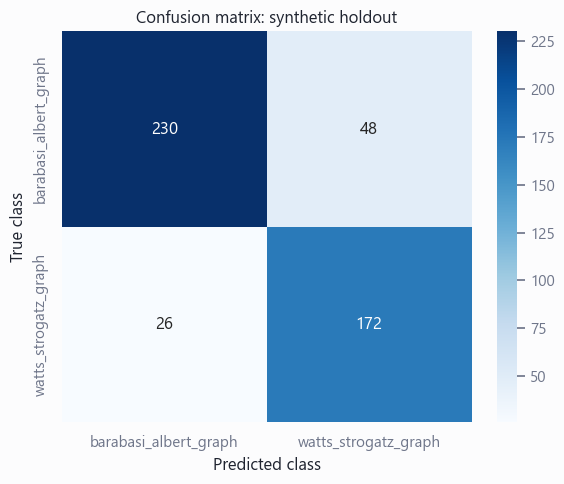

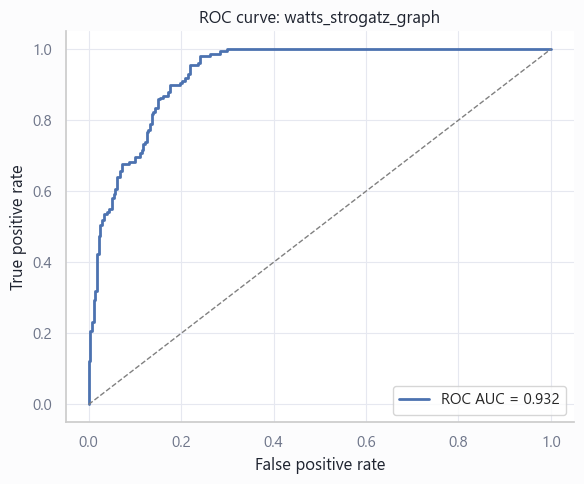

In [76]:
cm = confusion_matrix(y_test, test_pred, labels=classes)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)
plt.title("Confusion matrix: synthetic holdout")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

if len(classes) == 2:
    fpr, tpr, _ = roc_curve((y_test == positive_class).astype(int), test_proba[:, 1])
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    plt.title(f"ROC curve: {positive_class}")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

## 8. Важность признаков

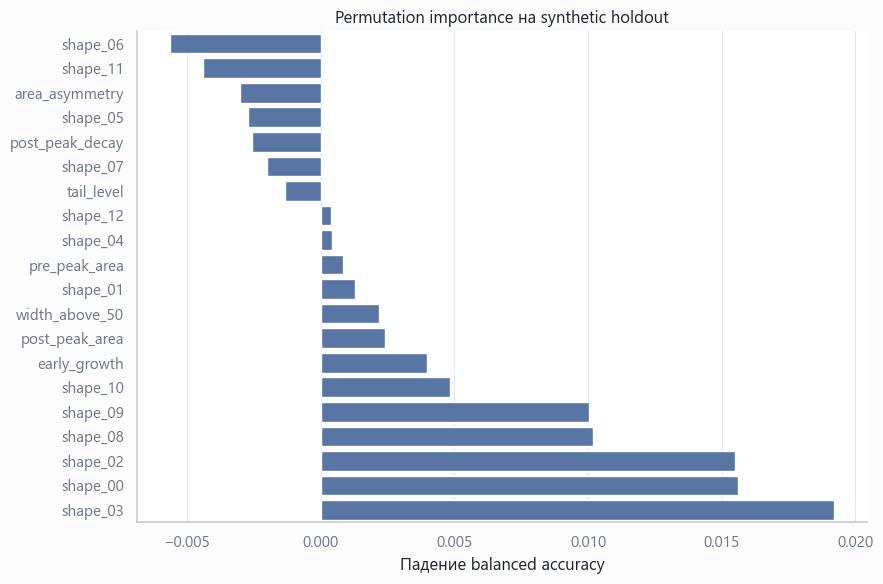

,feature,importance_mean,importance_std
0,shape_03,0.019186,0.007020
1,shape_00,0.015590,0.005568
2,shape_02,0.015480,0.009908
3,shape_08,0.010166,0.006524
4,shape_09,0.010027,0.003714
5,shape_10,0.004819,0.003790
6,early_growth,0.003976,0.006799
7,post_peak_area,0.002420,0.004459
8,width_above_50,0.002165,0.004243
9,shape_01,0.001294,0.005225


In [77]:
permutation = permutation_importance(
    calibrated_model,
    X_test,
    y_test,
    scoring="balanced_accuracy",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

feature_importance = (
    pd.DataFrame(
        {
            "feature": FEATURE_COLUMNS,
            "importance_mean": permutation.importances_mean,
            "importance_std": permutation.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 6))
top_features = feature_importance.head(20).sort_values("importance_mean", ascending=True)
sns.barplot(data=top_features, x="importance_mean", y="feature", color="#4C72B0")
plt.title("Permutation importance на synthetic holdout")
plt.xlabel("Падение balanced accuracy")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(feature_importance.head(20))

## 9. Калибровка слабой классификации
Низкая уверенность определяется по synthetic holdout: городская волна считается слабой,
если её `confidence` или `probability_margin` ниже 10-го перцентиля среди правильно
классифицированных синтетических волн того же предсказанного класса.

In [78]:
correct_holdout = synthetic_holdout_predictions[synthetic_holdout_predictions["is_correct"]].copy()


def reference_values_for_class(predicted_class, column):
    values = correct_holdout.loc[
        correct_holdout["predicted_class"] == predicted_class, column
    ].dropna()
    if values.empty:
        values = correct_holdout[column].dropna()
    return values.to_numpy(dtype=float)


def percentile_rank(value, reference):
    reference = np.asarray(reference, dtype=float)
    reference = reference[np.isfinite(reference)]
    if reference.size == 0 or not np.isfinite(value):
        return np.nan
    return float((reference <= float(value)).mean() * 100.0)


threshold_rows = []
for class_name in classes:
    confidence_reference = reference_values_for_class(class_name, "confidence")
    margin_reference = reference_values_for_class(class_name, "probability_margin")
    threshold_rows.append(
        {
            "predicted_class": class_name,
            "confidence_q10": float(np.quantile(confidence_reference, WEAK_PERCENTILE / 100)),
            "margin_q10": float(np.quantile(margin_reference, WEAK_PERCENTILE / 100)),
            "n_correct_holdout_reference": int(len(confidence_reference)),
        }
    )

confidence_thresholds = pd.DataFrame(threshold_rows)
display(confidence_thresholds)

,predicted_class,confidence_q10,margin_q10,n_correct_holdout_reference
0,barabasi_albert_graph,0.817514,0.635028,230
1,watts_strogatz_graph,0.633804,0.267608,172


## 10. Классификация городских волн

In [79]:
city_proba = calibrated_model.predict_proba(city_features[FEATURE_COLUMNS])
sorted_city_proba = np.sort(city_proba, axis=1)
city_pred_idx = np.argmax(city_proba, axis=1)
city_pred = classes[city_pred_idx]
city_confidence = sorted_city_proba[:, -1]
city_margin = (
    sorted_city_proba[:, -1] - sorted_city_proba[:, -2]
    if len(classes) > 1
    else np.ones(len(city_proba), dtype=float)
)

wave_classification = city_waves[
    ["city", "wave_id", "peak_year", "peak_week", "peak_value"]
].copy()
wave_classification["predicted_class"] = city_pred
for class_idx, class_name in enumerate(classes):
    wave_classification[f"prob_{class_name}"] = city_proba[:, class_idx]
wave_classification["confidence"] = city_confidence
wave_classification["probability_margin"] = city_margin

confidence_percentiles = []
margin_percentiles = []
weak_flags = []

threshold_lookup = confidence_thresholds.set_index("predicted_class")
for row in wave_classification.itertuples(index=False):
    confidence_ref = reference_values_for_class(row.predicted_class, "confidence")
    margin_ref = reference_values_for_class(row.predicted_class, "probability_margin")
    confidence_percentile = percentile_rank(row.confidence, confidence_ref)
    margin_percentile = percentile_rank(row.probability_margin, margin_ref)

    confidence_threshold = float(threshold_lookup.loc[row.predicted_class, "confidence_q10"])
    margin_threshold = float(threshold_lookup.loc[row.predicted_class, "margin_q10"])

    confidence_percentiles.append(confidence_percentile)
    margin_percentiles.append(margin_percentile)
    weak_flags.append(
        bool(
            row.confidence < confidence_threshold
            or row.probability_margin < margin_threshold
        )
    )

wave_classification["absolute_confidence_percentile"] = confidence_percentiles
wave_classification["absolute_margin_percentile"] = margin_percentiles
wave_classification["weak_match"] = weak_flags

probability_columns = [f"prob_{class_name}" for class_name in classes]
probability_sums = wave_classification[probability_columns].sum(axis=1)
if not np.allclose(probability_sums, 1.0, atol=1e-8):
    raise ValueError("Вероятности классов для городских волн не суммируются до 1")

display(wave_classification.sort_values(["city", "wave_id"]).reset_index(drop=True))

,city,wave_id,peak_year,peak_week,peak_value,predicted_class,prob_barabasi_albert_graph,prob_watts_strogatz_graph,confidence,probability_margin,absolute_confidence_percentile,absolute_margin_percentile,weak_match
0,Екатеринбург,1,1986,47,19472.000000,barabasi_albert_graph,0.934350,0.065650,0.934350,0.868700,15.652174,15.652174,False
1,Екатеринбург,2,1988,8,31723.000000,barabasi_albert_graph,0.969639,0.030361,0.969639,0.939277,23.043478,23.043478,False
2,Екатеринбург,3,1989,9,21734.000000,barabasi_albert_graph,0.682778,0.317222,0.682778,0.365556,7.826087,7.826087,True
3,Екатеринбург,4,1989,52,9864.333333,watts_strogatz_graph,0.426266,0.573734,0.573734,0.147468,4.069767,4.069767,True
4,Екатеринбург,5,1990,5,19993.000000,barabasi_albert_graph,0.593807,0.406193,0.593807,0.187614,4.347826,4.347826,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,Челябинск,26,2011,5,19866.000000,barabasi_albert_graph,0.558358,0.441642,0.558358,0.116717,2.173913,2.173913,True
321,Челябинск,27,2012,12,13098.333333,watts_strogatz_graph,0.047441,0.952559,0.952559,0.905118,91.279070,91.279070,False
322,Челябинск,28,2013,7,19020.666667,watts_strogatz_graph,0.278522,0.721478,0.721478,0.442956,21.511628,21.511628,False
323,Челябинск,29,2014,10,14230.666667,watts_strogatz_graph,0.117308,0.882692,0.882692,0.765384,57.558140,57.558140,False


## 11. Диагностика городских результатов

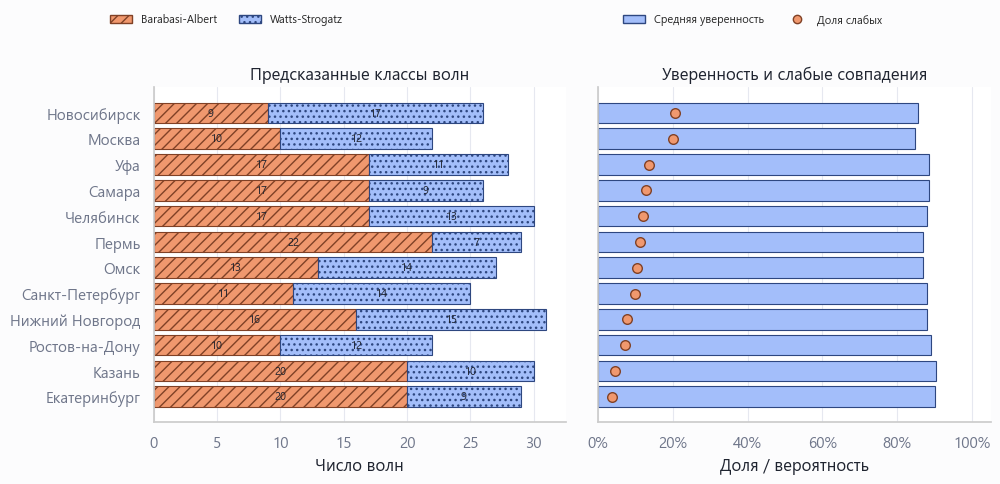

In [80]:
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

CLASS_DISPLAY = {
    "barabasi_albert_graph": "Barabasi-Albert",
    "watts_strogatz_graph": "Watts-Strogatz",
}
CLASS_COLORS = {
    "barabasi_albert_graph": "#F0986E",
    "watts_strogatz_graph": "#A3BEFA",
}
CLASS_EDGES = {
    "barabasi_albert_graph": "#804126",
    "watts_strogatz_graph": "#2E4780",
}
CLASS_HATCHES = {
    "barabasi_albert_graph": "///",
    "watts_strogatz_graph": "...",
}
TOKENS = {
    "surface": "#FCFCFD",
    "panel": "#FFFFFF",
    "ink": "#1F2430",
    "muted": "#6F768A",
    "grid": "#E6E8F0",
}

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": TOKENS["surface"],
        "axes.facecolor": TOKENS["panel"],
        "axes.labelcolor": TOKENS["ink"],
        "axes.titlecolor": TOKENS["ink"],
        "xtick.color": TOKENS["muted"],
        "ytick.color": TOKENS["muted"],
        "grid.color": TOKENS["grid"],
        "grid.linewidth": 0.8,
        "font.family": "sans-serif",
        "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial", "sans-serif"],
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

def save_figure(fig, filename):
    display(fig)
    plt.close(fig)


def plot_city_summary(ns):
    waves = ns["wave_classification"].copy()
    summary = ns["city_summary"].copy()
    graph_kinds = ns["GRAPH_KINDS"]
    summary["city_label"] = summary["city"].str.replace("_", " ", regex=False)
    summary = summary.sort_values(["main_class", "weak_match_share", "city_label"], ascending=[False, True, True]).reset_index(drop=True)
    counts = waves.groupby(["city", "predicted_class"]).size().unstack(fill_value=0)
    for cls in graph_kinds:
        if cls not in counts.columns:
            counts[cls] = 0
    counts = counts.reindex(summary["city"]).fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(10.8, 5.4), gridspec_kw={"width_ratios": [1.05, 1.0]})
    y = np.arange(len(summary))
    left = np.zeros(len(summary))
    for cls in graph_kinds:
        values = counts[cls].to_numpy(dtype=float)
        axes[0].barh(
            y,
            values,
            left=left,
            color=CLASS_COLORS[cls],
            edgecolor=CLASS_EDGES[cls],
            hatch=CLASS_HATCHES[cls],
            linewidth=0.8,
        )
        for i, value in enumerate(values):
            if value > 0:
                axes[0].text(left[i] + value / 2, i, f"{int(value)}", ha="center", va="center", fontsize=8, color=TOKENS["ink"])
        left += values
    axes[0].set_yticks(y, summary["city_label"])
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Число волн")
    axes[0].set_title("Предсказанные классы волн")

    axes[1].barh(y, summary["mean_confidence"], color="#A3BEFA", edgecolor="#2E4780", linewidth=0.8, label="Средняя уверенность")
    axes[1].scatter(summary["weak_match_share"], y, color="#F0986E", edgecolor="#804126", s=48, zorder=3, label="Доля слабых")
    axes[1].set_yticks(y, [""] * len(summary))
    axes[1].set_xlim(0, 1.05)
    axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].set_xlabel("Доля / вероятность")
    axes[1].set_title("Уверенность и слабые совпадения")
    for ax in axes:
        ax.grid(axis="x", color=TOKENS["grid"])
        ax.grid(axis="y", visible=False)
    class_handles = [
        Patch(
            facecolor=CLASS_COLORS[cls],
            edgecolor=CLASS_EDGES[cls],
            hatch=CLASS_HATCHES[cls],
            label=CLASS_DISPLAY[cls],
        )
        for cls in graph_kinds
    ]
    metric_handles = [
        Patch(facecolor="#A3BEFA", edgecolor="#2E4780", label="Средняя уверенность"),
        Line2D([], [], marker="o", linestyle="", markerfacecolor="#F0986E", markeredgecolor="#804126", label="Доля слабых"),
    ]
    fig.legend(handles=class_handles, loc="upper left", bbox_to_anchor=(0.075, 0.885), frameon=False, ncol=2, fontsize=8)
    fig.legend(handles=metric_handles, loc="upper left", bbox_to_anchor=(0.55, 0.885), frameon=False, ncol=2, fontsize=8)
    fig.subplots_adjust(top=0.73, wspace=0.08)
    save_figure(fig, "city_classification_summary.pdf")


analysis = {
    "wave_classification": wave_classification,
    "city_summary": city_summary,
    "GRAPH_KINDS": GRAPH_KINDS,
}

plot_city_summary(analysis)

## 12. Примеры уверенных и слабых городских волн

,city,wave_id,predicted_class,confidence,probability_margin,weak_match
0,Казань,13,barabasi_albert_graph,0.974420,0.948839,False
1,Самара,16,barabasi_albert_graph,0.970728,0.941455,False
2,Уфа,2,barabasi_albert_graph,0.970102,0.940203,False
3,Омск,26,barabasi_albert_graph,0.501385,0.002770,True
4,Казань,29,barabasi_albert_graph,0.512149,0.024298,True
5,Омск,11,barabasi_albert_graph,0.513759,0.027519,True


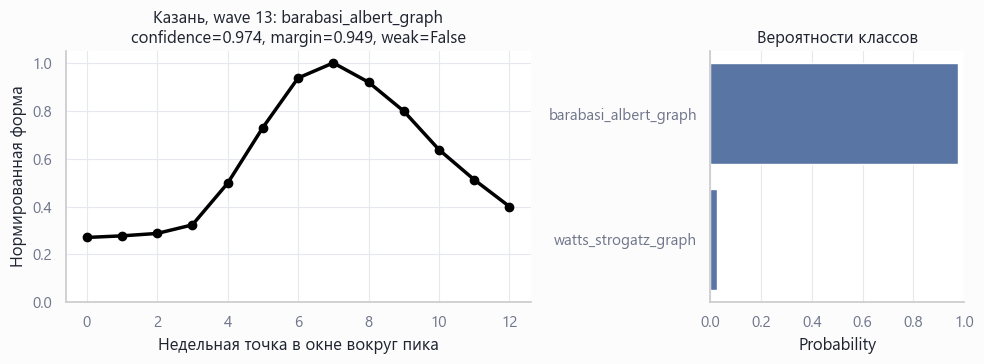

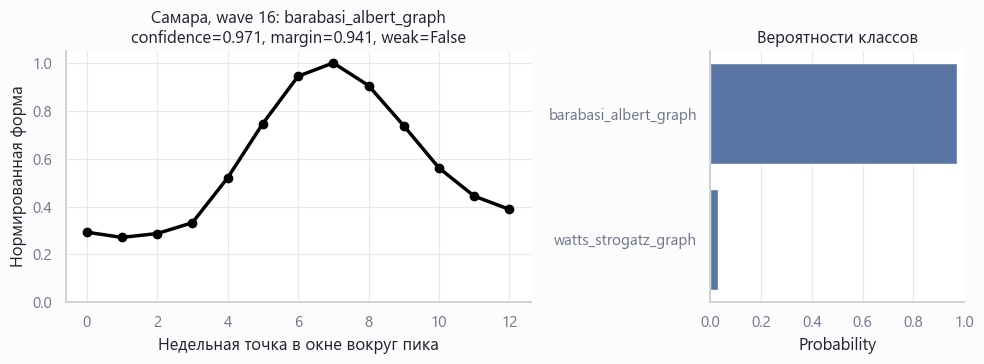

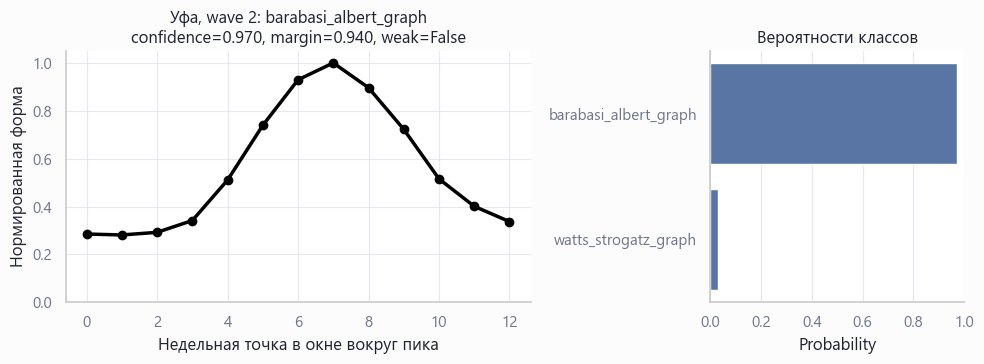

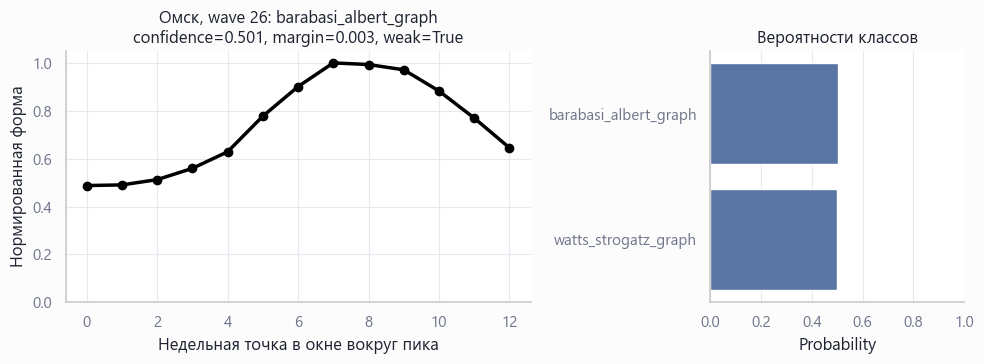

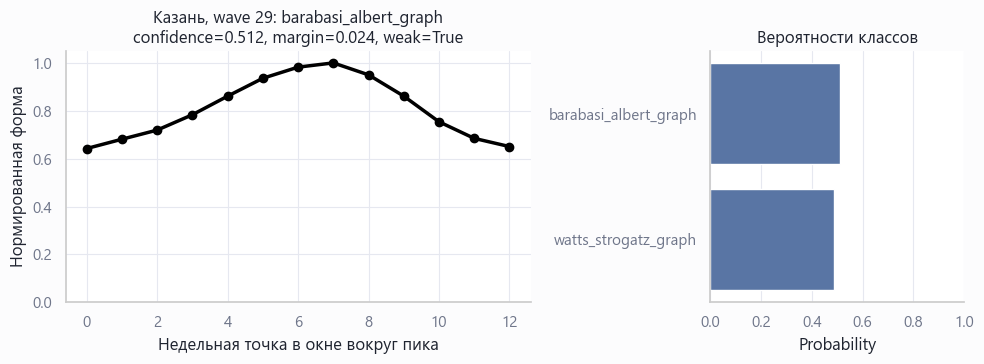

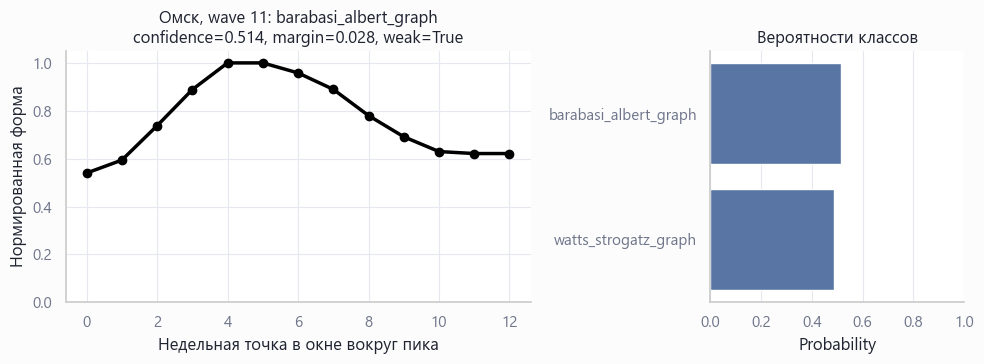

In [81]:
def plot_wave(city, wave_id):
    wave = city_waves[(city_waves["city"] == city) & (city_waves["wave_id"] == wave_id)].iloc[0]
    result = wave_classification[
        (wave_classification["city"] == city)
        & (wave_classification["wave_id"] == wave_id)
    ].iloc[0]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 3.8),
        gridspec_kw={"width_ratios": [2.2, 1.2]},
    )
    x = np.arange(CITY_WINDOW_POINTS)
    axes[0].plot(x, wave["shape"], color="black", linewidth=2.5, marker="o")
    axes[0].set_title(
        f"{city}, wave {wave_id}: {result.predicted_class}\n"
        f"confidence={result.confidence:.3f}, margin={result.probability_margin:.3f}, "
        f"weak={bool(result.weak_match)}"
    )
    axes[0].set_xlabel("Недельная точка в окне вокруг пика")
    axes[0].set_ylabel("Нормированная форма")
    axes[0].set_ylim(0, 1.05)

    prob_values = [float(result[f"prob_{class_name}"]) for class_name in classes]
    sns.barplot(x=prob_values, y=classes, orient="h", ax=axes[1], color="#4C72B0")
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probability")
    axes[1].set_ylabel("")
    axes[1].set_title("Вероятности классов")

    plt.tight_layout()
    plt.show()


confident_examples = (
    wave_classification
    .sort_values(["weak_match", "confidence"], ascending=[True, False])
    .head(3)
)
weak_examples = (
    wave_classification[wave_classification["weak_match"]]
    .sort_values(["confidence", "probability_margin"], ascending=[True, True])
    .head(3)
)
examples = (
    pd.concat([confident_examples, weak_examples], ignore_index=True)
    .drop_duplicates(["city", "wave_id"])
    .head(6)
)

display(examples[["city", "wave_id", "predicted_class", "confidence", "probability_margin", "weak_match"]])
for row in examples.itertuples(index=False):
    plot_wave(row.city, int(row.wave_id))

# 13. Дополнительно: визуализация данных

## Реальные данные

### 13.1. Без предобработки

In [82]:
plot_data = []
for i in range(len(city_waves)):
    city = city_waves.iloc[i]['city']
    start_date = (city_waves.iloc[i]['start_year'], city_waves.iloc[i]['start_week'])
    end_date = (city_waves.iloc[i]['end_year'], city_waves.iloc[i]['end_week'])
    
    bad_number = 0
    if (start_date[0] != end_date[0]):
        # Можно ещё счетчик сделать
        #print('Разные года, потом подумаю')
        bad_number += 1
        continue
    else:
        temp_data = city_df[(city_df['town_name'] == city) & (city_df['cld_year'] == start_date[0]) &
                            (city_df['week_number'] >= start_date[1]) & (city_df['week_number'] <= end_date[1])]
            
    
    plot_data.append([city, temp_data['wd_total'], temp_data['week_number']])
    

In [83]:
unique_cities = set(item[0] for item in plot_data)
unique_cities

{'Екатеринбург',
 'Казань',
 'Москва',
 'Нижний_Новгород',
 'Новосибирск',
 'Омск',
 'Пермь',
 'Ростов-на-Дону',
 'Самара',
 'Санкт-Петербург',
 'Уфа',
 'Челябинск'}

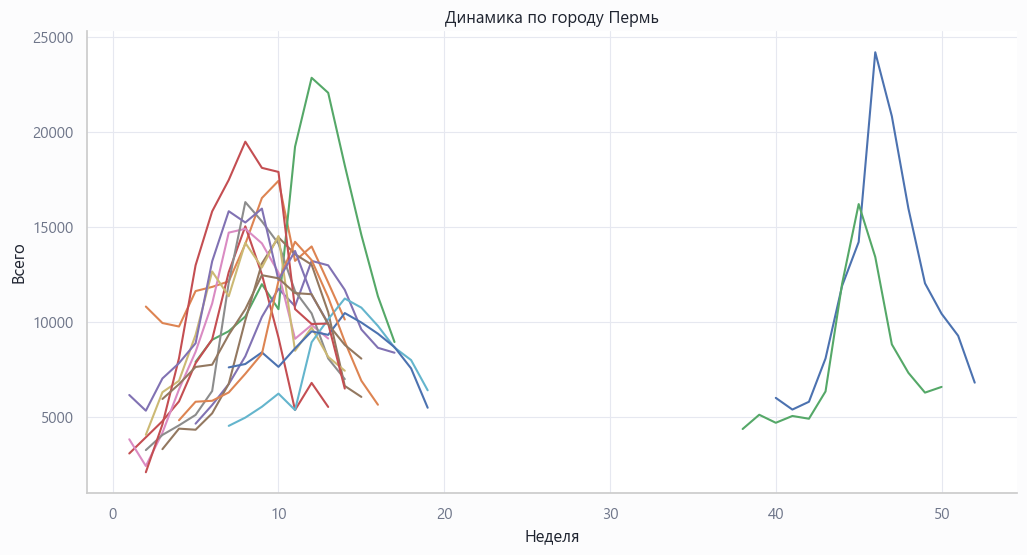

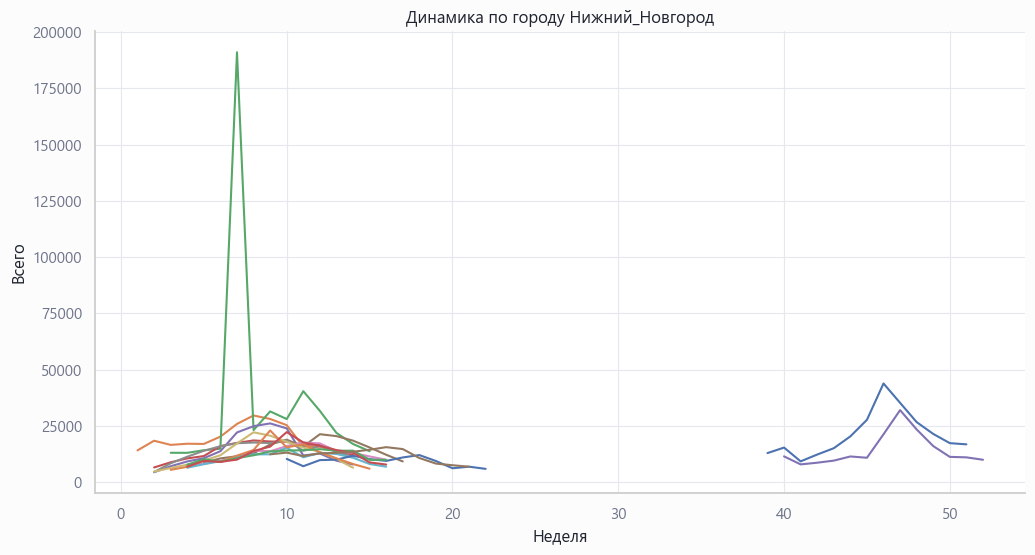

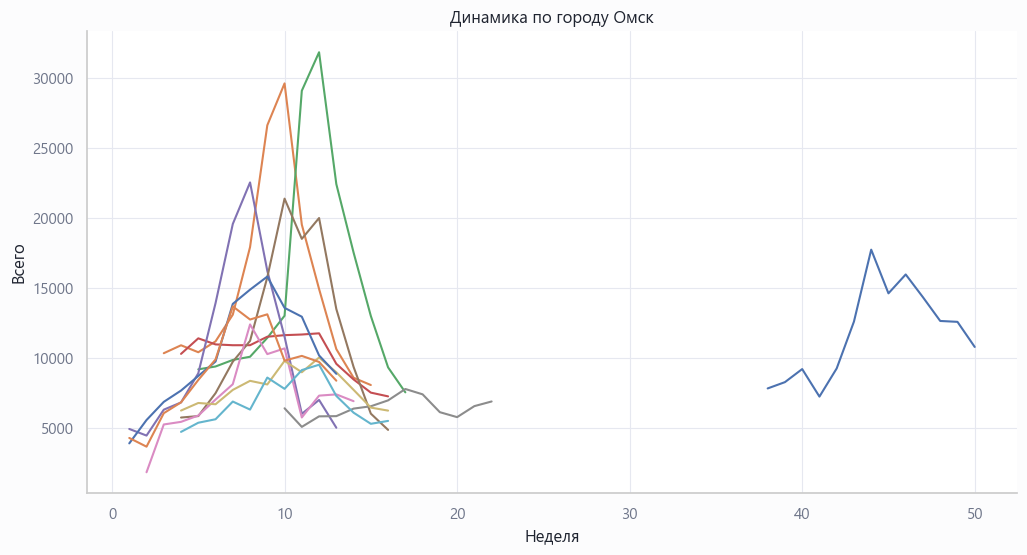

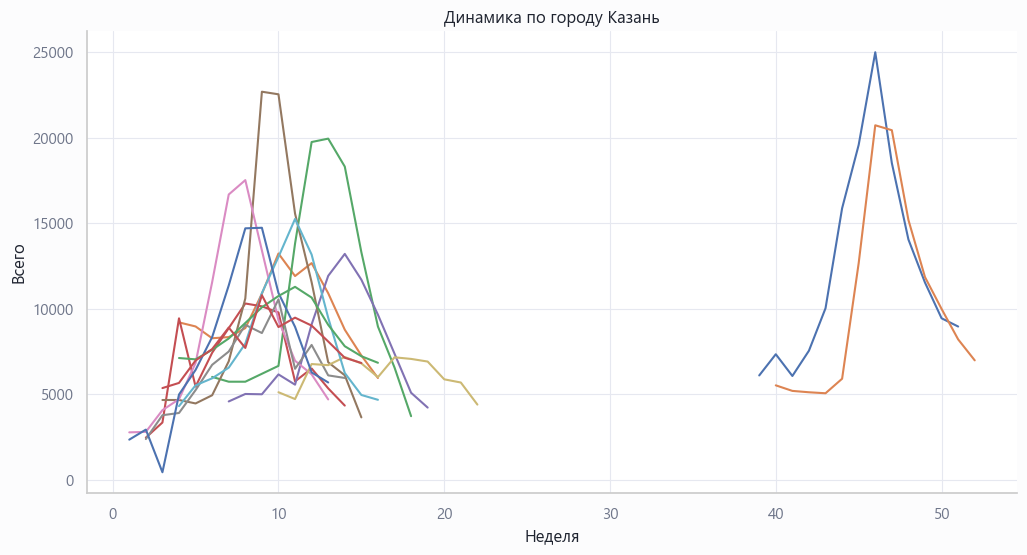

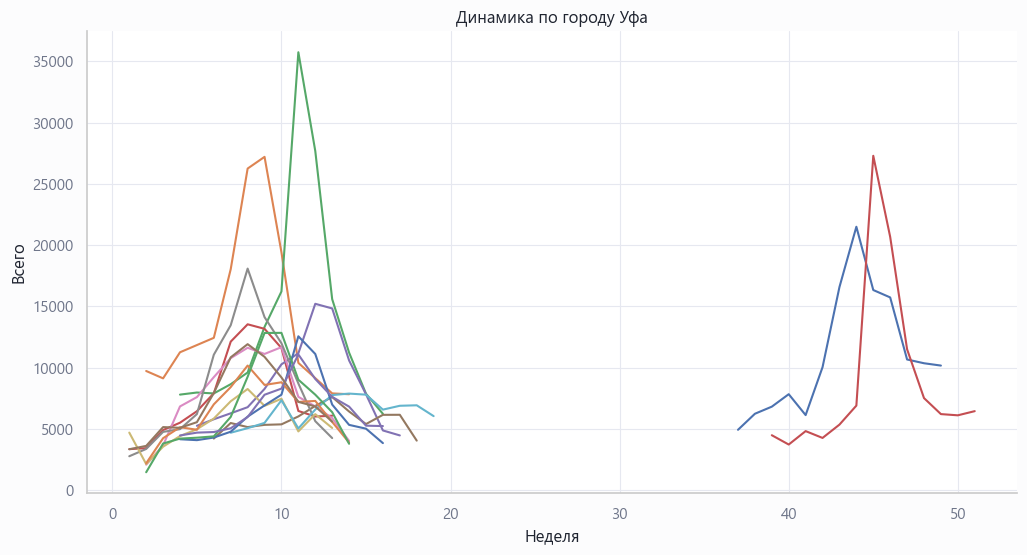

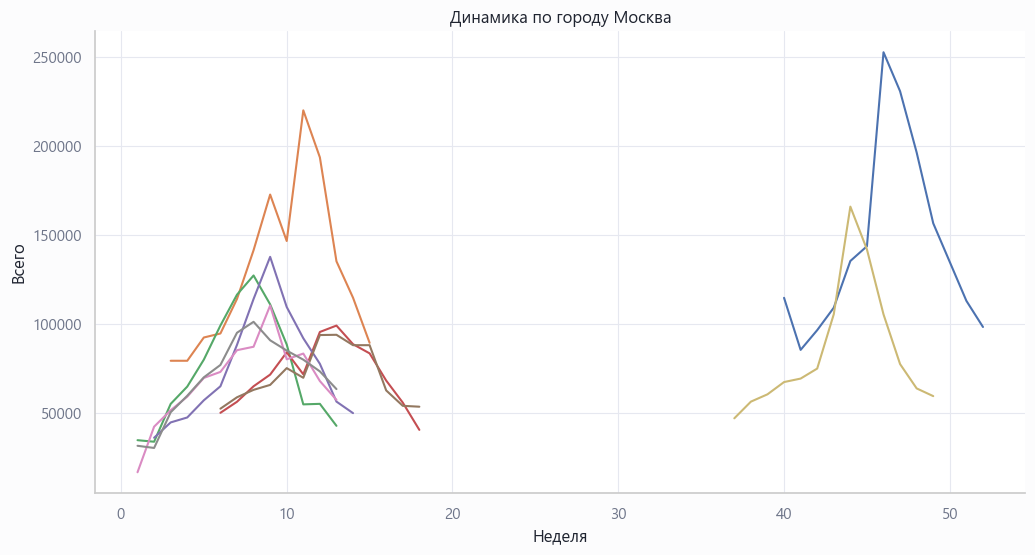

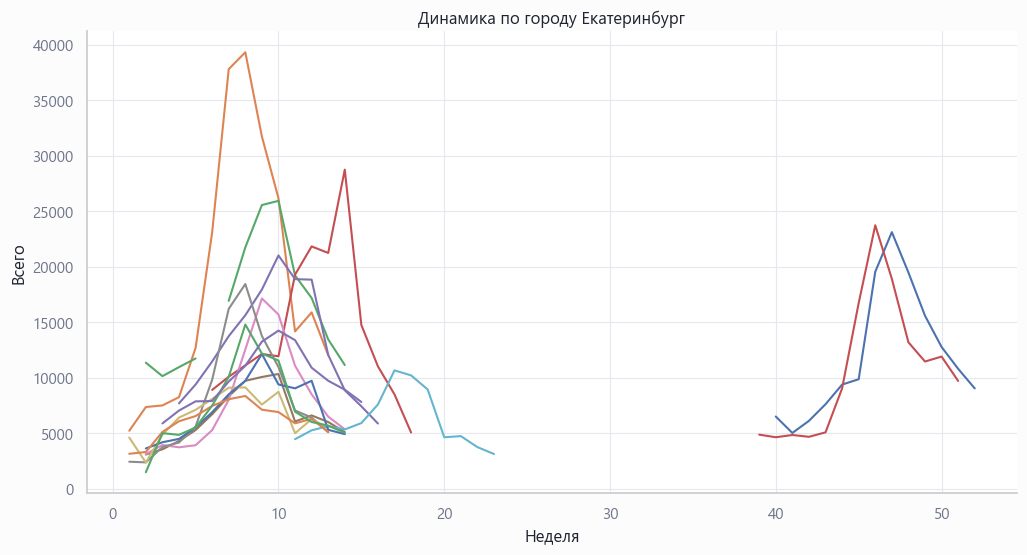

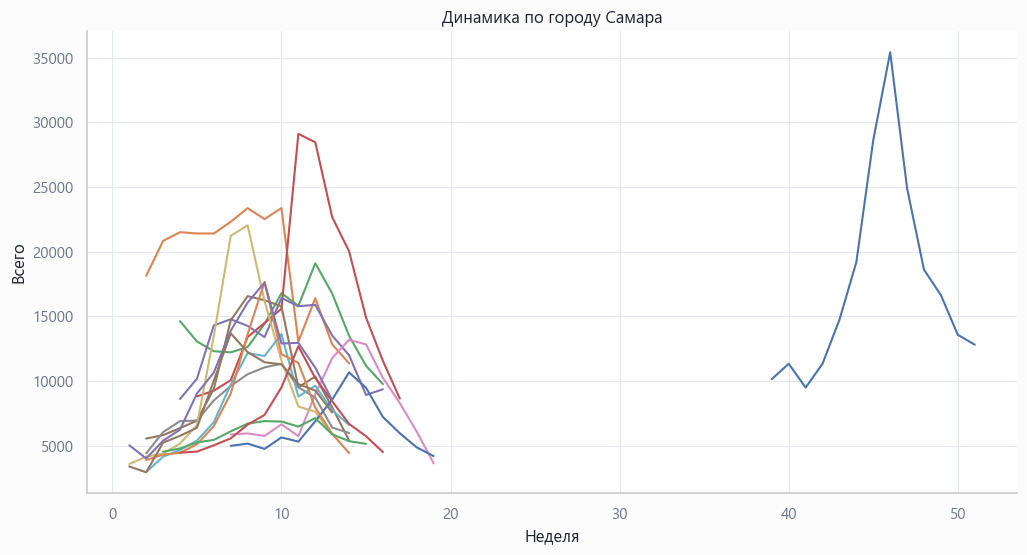

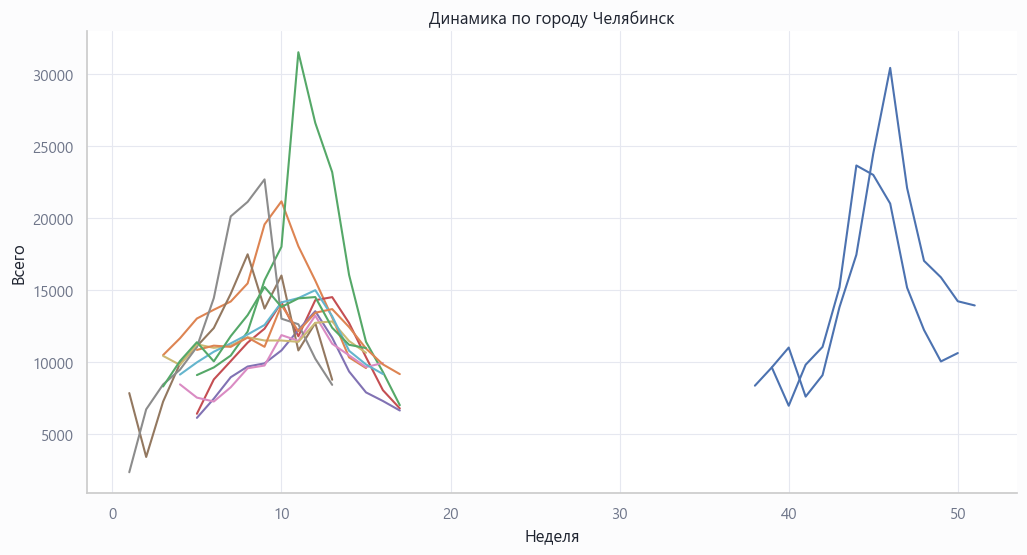

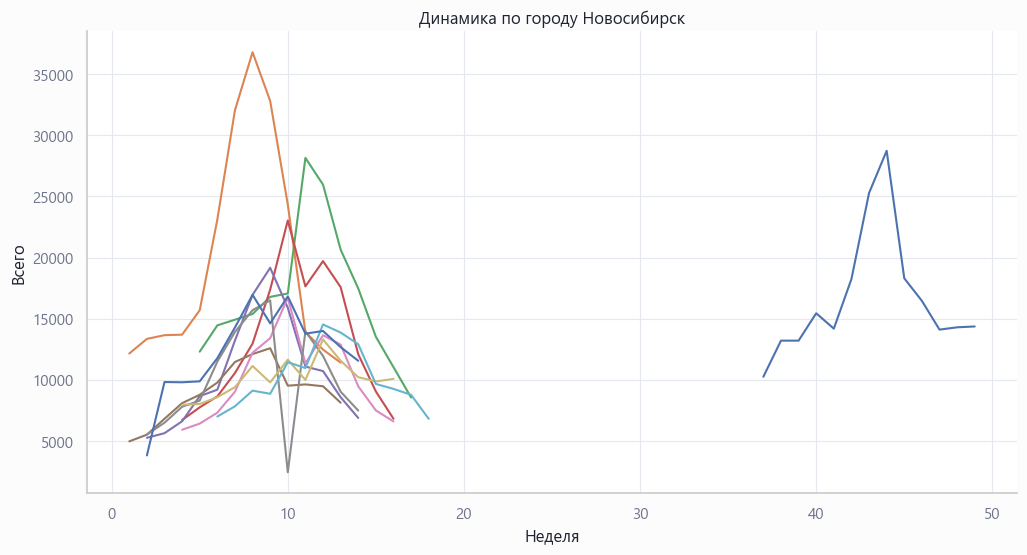

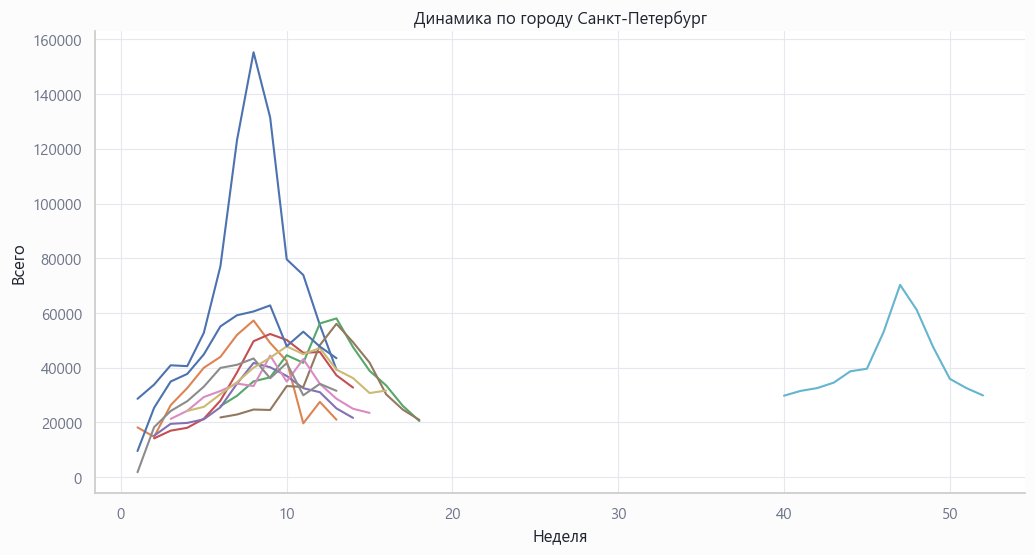

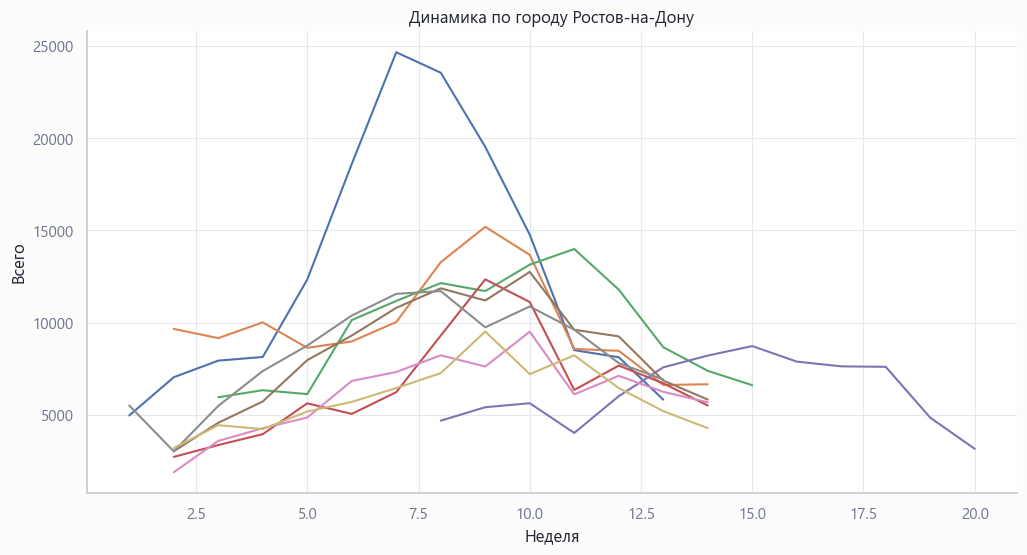

In [84]:
for city in unique_cities:    
    filtered_data = [item for item in plot_data if item[0] == city]

    plt.figure(figsize=(12, 6))

    for city_data in filtered_data:
        plt.plot(city_data[2], city_data[1], label=city_data[0])

    plt.xlabel('Неделя')
    plt.ylabel('Всего')
    plt.title(f'Динамика по городу {city}')
    #plt.legend()
    plt.grid(True)
    plt.show()

### 13.2. Для сглаженных данных

In [85]:
smooth_plot_data = []
for i in range(len(city_waves)):
    city = city_waves.iloc[i]['city']
    start_date = (city_waves.iloc[i]['start_year'], city_waves.iloc[i]['start_week'])
    end_date = (city_waves.iloc[i]['end_year'], city_waves.iloc[i]['end_week'])
    
    bad_number = 0
    if (start_date[0] != end_date[0]):
        # Можно ещё счетчик сделать
        #print('Разные года, потом подумаю')
        bad_number += 1
        continue
    else:
        temp_group = city_df[city_df['town_name'] == city].sort_values(['cld_year', 'week_number']).reset_index(drop=True)
        smooth_series = smooth_city_series(temp_group)
        temp_data = temp_group[(temp_group['cld_year'] == start_date[0]) &
                               (temp_group['week_number'] >= start_date[1]) & (temp_group['week_number'] <= end_date[1])].copy()
        temp_data['wd_total_smooth'] = smooth_series[temp_data.index]
            
    
    smooth_plot_data.append([city, temp_data['wd_total_smooth'], temp_data['week_number']])

In [86]:
unique_smooth_cities = set(item[0] for item in smooth_plot_data)
unique_smooth_cities

{'Екатеринбург',
 'Казань',
 'Москва',
 'Нижний_Новгород',
 'Новосибирск',
 'Омск',
 'Пермь',
 'Ростов-на-Дону',
 'Самара',
 'Санкт-Петербург',
 'Уфа',
 'Челябинск'}

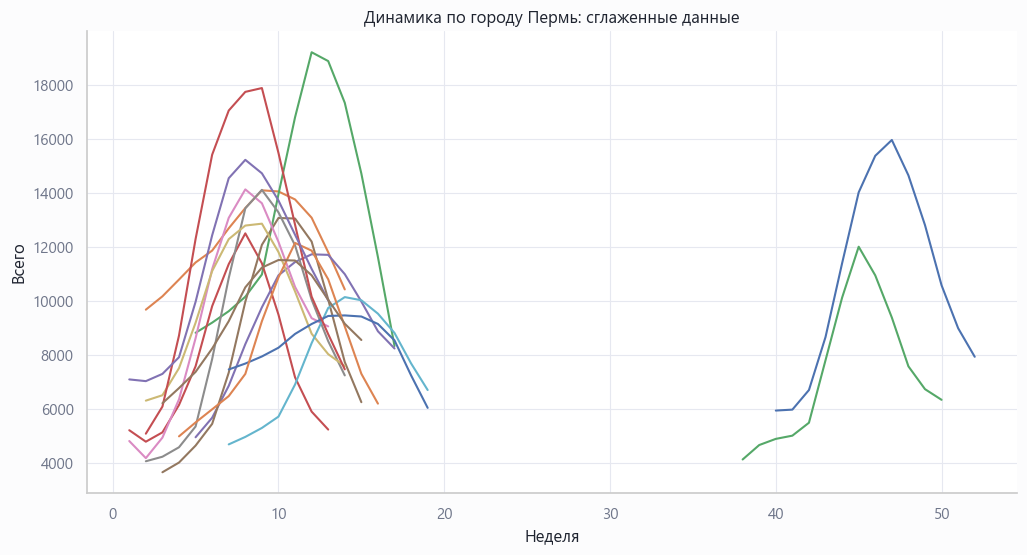

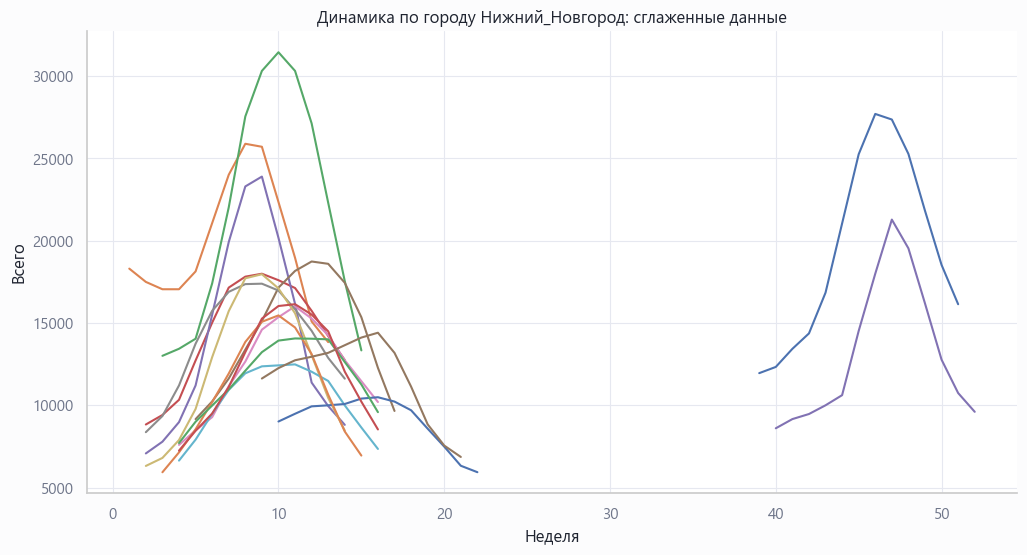

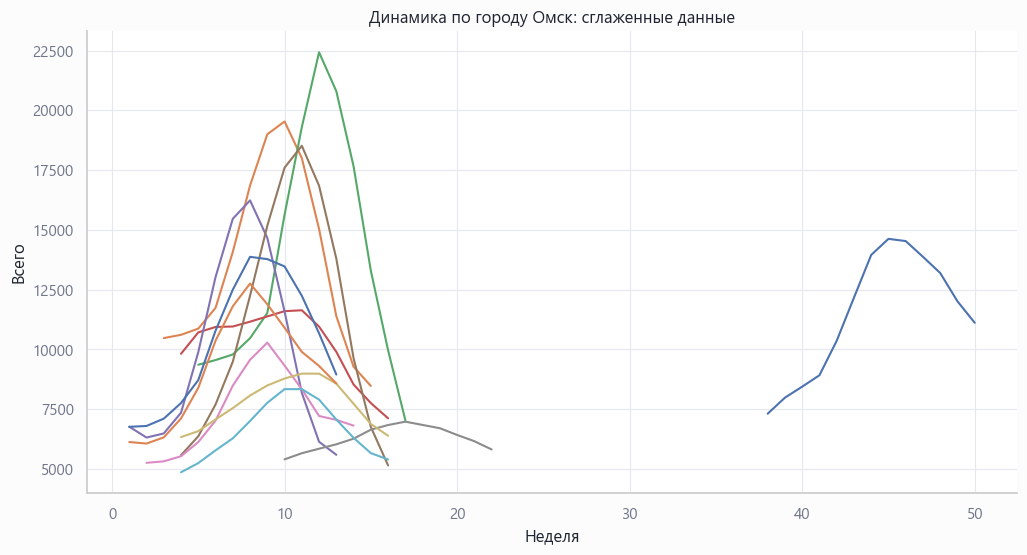

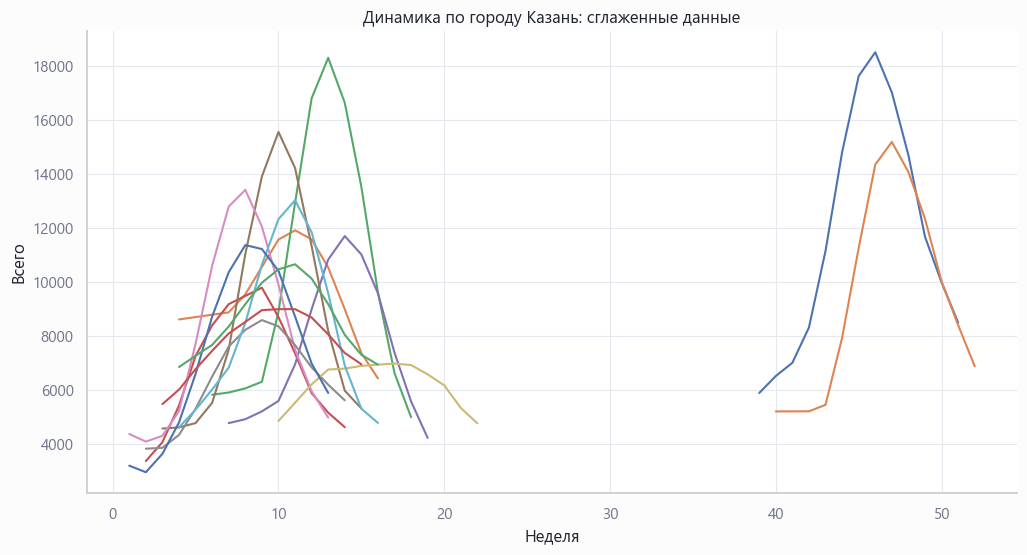

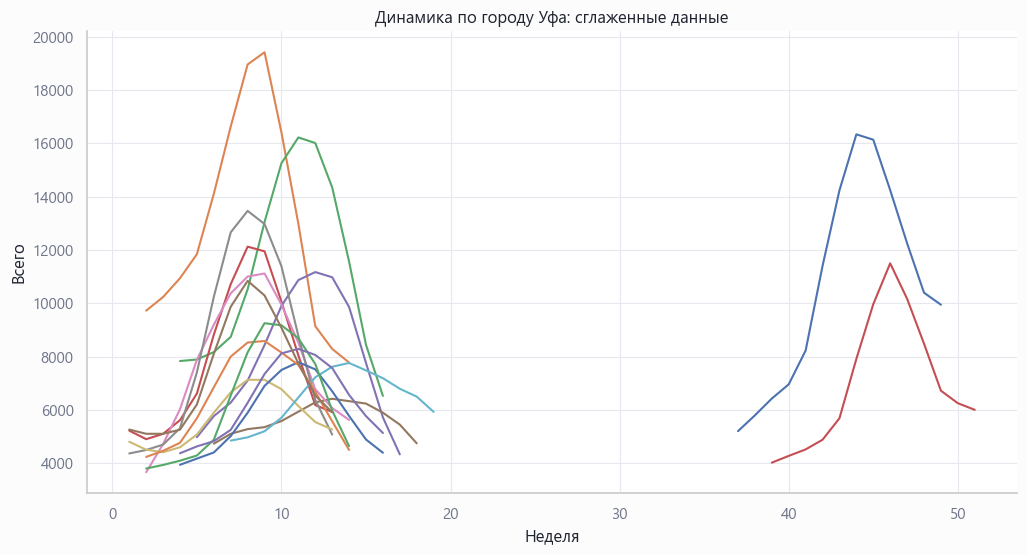

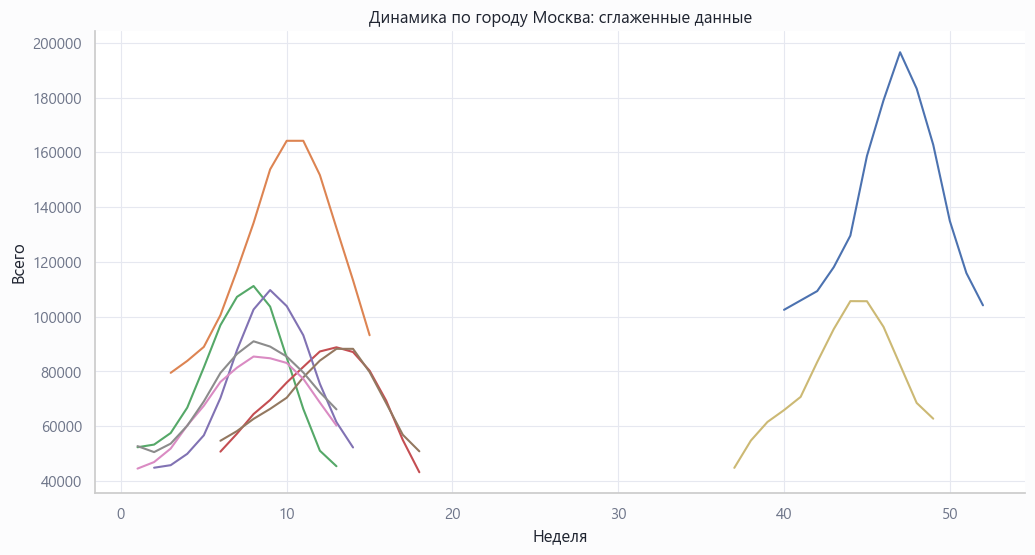

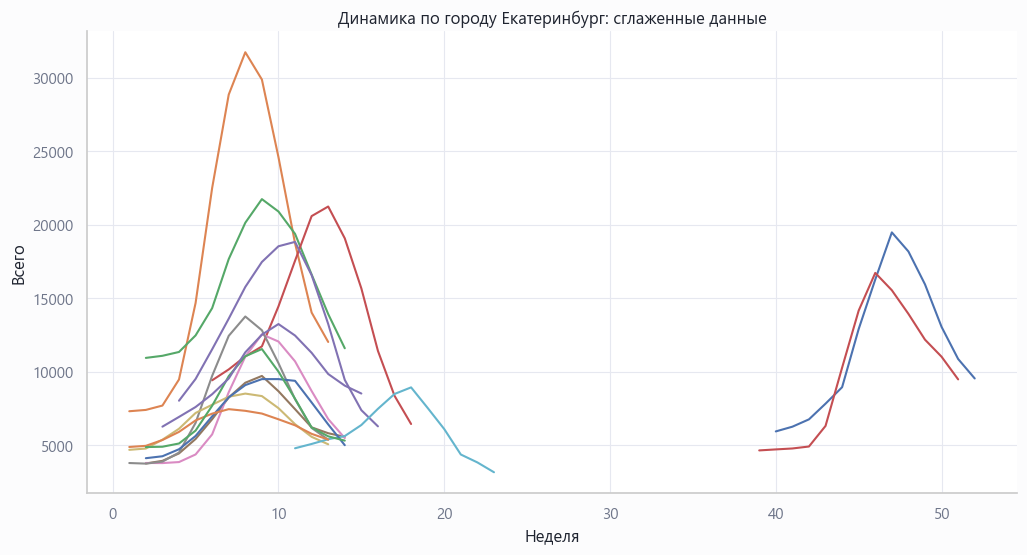

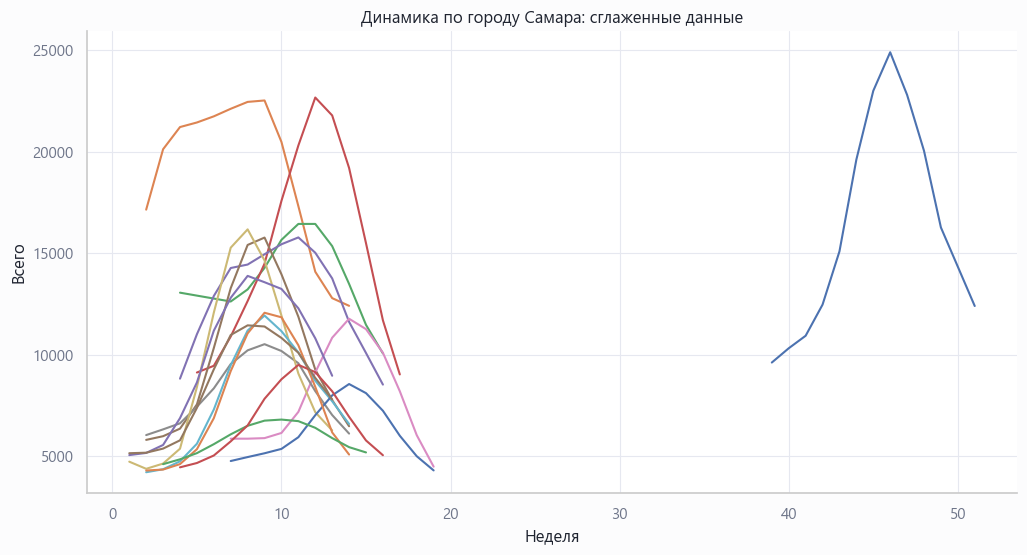

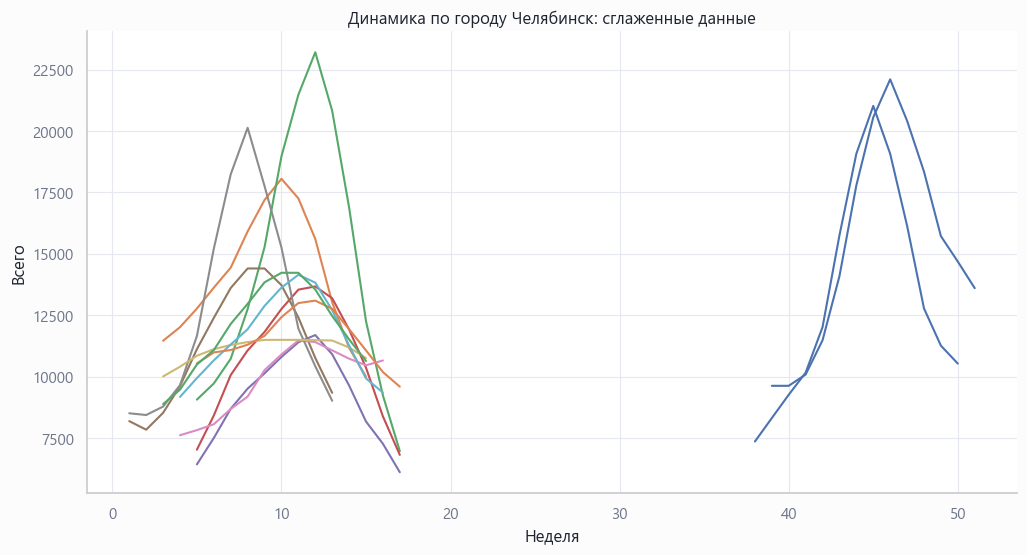

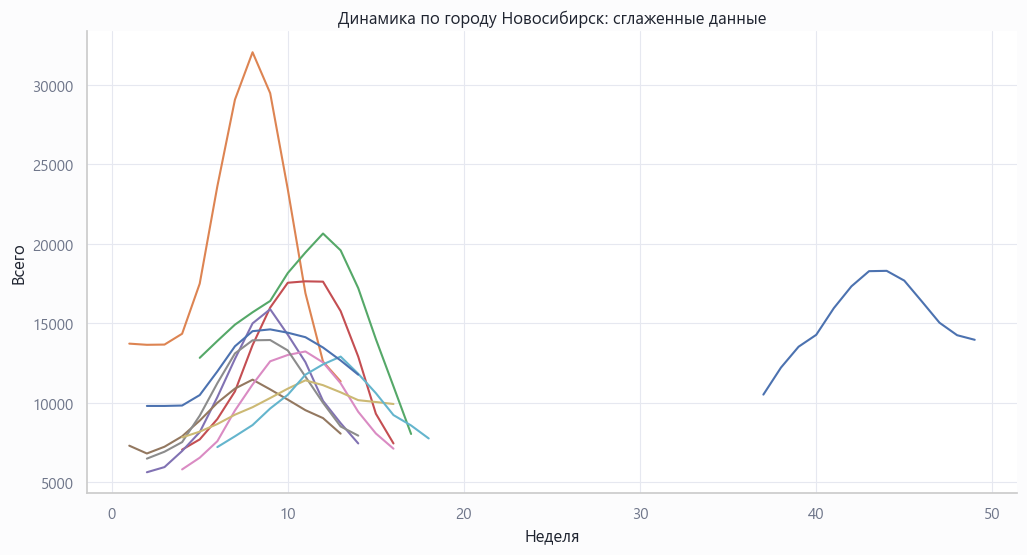

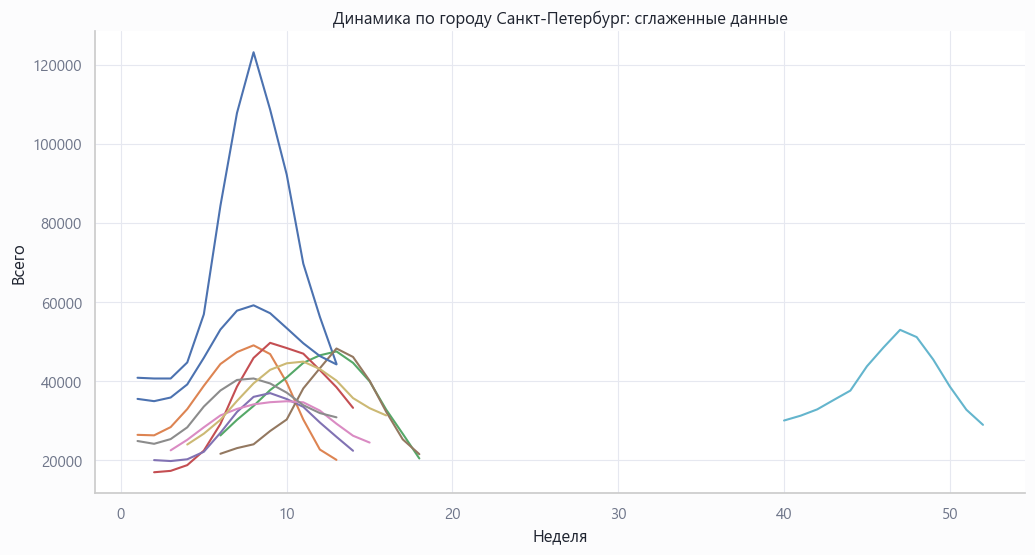

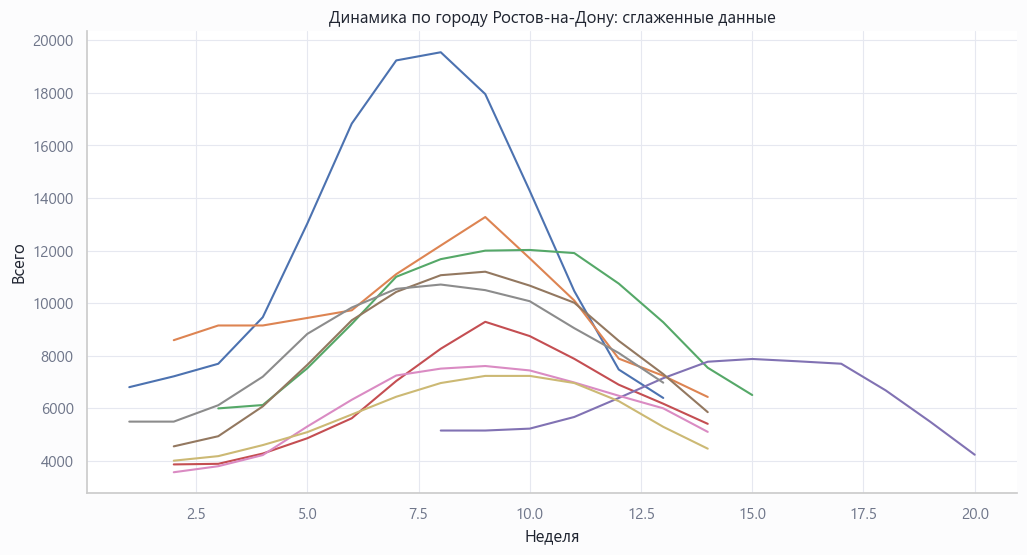

In [87]:
for city in unique_smooth_cities:    
    filtered_data = [item for item in smooth_plot_data if item[0] == city]

    plt.figure(figsize=(12, 6))

    for city_data in filtered_data:
        plt.plot(city_data[2], city_data[1], label=city_data[0])

    plt.xlabel('Неделя')
    plt.ylabel('Всего')
    plt.title(f'Динамика по городу {city}: сглаженные данные')
    #plt.legend()
    plt.grid(True)
    plt.show()

## 13.3. Синтетические

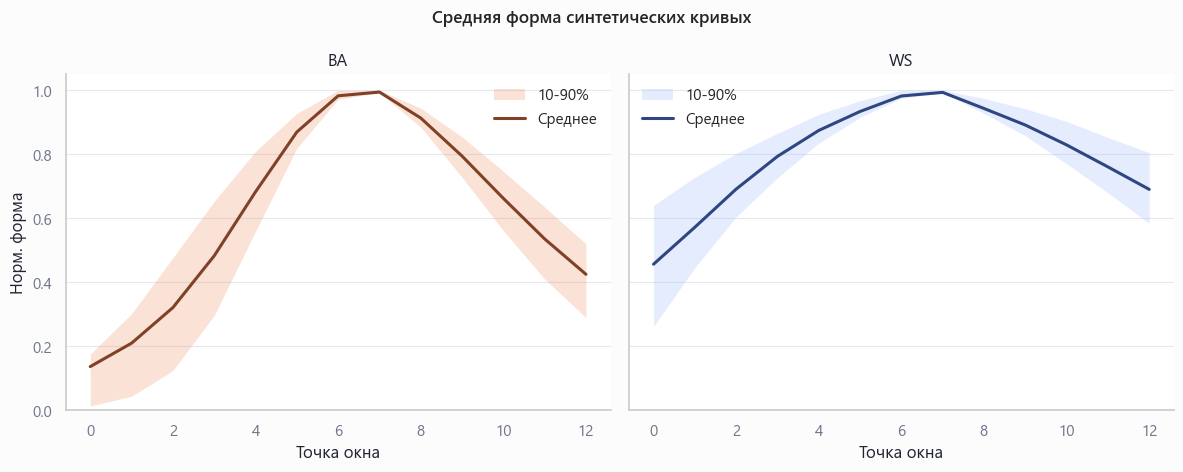

In [89]:
def collect_curves(df, graph_kind):
    curves = []
    for shape in df.loc[df["label"] == graph_kind, "shape"]:
        curve = np.asarray(shape, dtype=float)
        curves.append(curve)

    return np.vstack(curves)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True)

for ax, graph_kind, title in zip(
    axes,
    ["barabasi_albert_graph", "watts_strogatz_graph"],
    ["BA", "WS"],
):
    curves = collect_curves(synthetic_df, graph_kind)

    mean_curve = curves.mean(axis=0)
    lower = np.percentile(curves, 25, axis=0)
    upper = np.percentile(curves, 75, axis=0)

    x = np.arange(len(mean_curve))

    ax.fill_between(
        x,
        lower,
        upper,
        color=CLASS_COLORS.get(graph_kind, "#A3BEFA"),
        alpha=0.28,
        linewidth=0,
        label="10-90%",
    )
    ax.plot(
        x,
        mean_curve,
        color=CLASS_EDGES.get(graph_kind, "#2E4780"),
        linewidth=2.2,
        label="Среднее",
    )

    ax.set_title(title)
    ax.set_xlabel("Точка окна")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", color=TOKENS.get("grid", "#E6E8F0"))
    ax.grid(axis="x", visible=False)
    ax.legend(frameon=False)

axes[0].set_ylabel("Норм. форма")
fig.suptitle("Средняя форма синтетических кривых", fontsize=12.5, fontweight="semibold")
fig.tight_layout()
plt.show()